In [37]:
import os
import shutil
import kagglehub

# 1. Your token is working perfectly!
os.environ['KAGGLE_API_TOKEN'] = "KGAT_0035d60d198022b516959b4721ff2ea7"

# 2. Download the CORRECT dataset 
print("Downloading dataset...")
download_path = kagglehub.dataset_download("dionisiusdh/indonesian-batik-motifs")

# 3. Move it to our working folder so the rest of our code works
shutil.copytree(download_path, "batik_dataset", dirs_exist_ok=True)

print("Dataset downloaded and ready in the 'batik_dataset' folder!")

Using Colab cache for faster access to the 'indonesian-batik-motifs' dataset.
Dataset downloaded and ready in the 'batik_dataset' folder!


In [43]:
import os
from PIL import Image

data_dir = 'batik_dataset'
print("Starting Deep Cleaning...")

removed_count = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            # Try to physically open and verify the image data
            img = Image.open(file_path)
            img.verify() 
        except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
            # If the file is corrupted or not a real image, delete it
            os.remove(file_path)
            removed_count += 1
            print(f"Removed broken file: {file_path}")

print(f"Done! Deep cleaning removed {removed_count} problematic files.")

Starting Deep Cleaning...
Removed broken file: batik_dataset/batik-cendrawasih/18.jpg
Removed broken file: batik_dataset/batik-megamendung/49.jpg
Done! Deep cleaning removed 2 problematic files.


In [44]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Define parameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
DATA_DIR = 'batik_dataset'

# 1. Create the Training Dataset (80% of the data)
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Create the Validation Dataset (20% of the data)
val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 3. Get the list of Batik Motif names
class_names = train_ds.class_names
print(f"Batik motifs found: {class_names}")

# 4. Optimize performance by loading data into memory (Autotune)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 981 files belonging to 20 classes.
Using 785 files for training.
Found 981 files belonging to 20 classes.
Using 196 files for validation.
Batik motifs found: ['batik-bali', 'batik-betawi', 'batik-celup', 'batik-cendrawasih', 'batik-ceplok', 'batik-ciamis', 'batik-garutan', 'batik-gentongan', 'batik-kawung', 'batik-keraton', 'batik-lasem', 'batik-megamendung', 'batik-parang', 'batik-pekalongan', 'batik-priangan', 'batik-sekar', 'batik-sidoluhur', 'batik-sidomukti', 'batik-sogan', 'batik-tambal']


In [45]:
from tensorflow.keras import layers, models

# 1. Define the Baseline Architecture
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)), # Normalize pixels to [0,1]
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax') # Output layer for 20 classes
])

# 2. Compile
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model for 10 epochs
print("Starting training...")
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Starting training...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.0404 - loss: 7.7166 - val_accuracy: 0.0408 - val_loss: 2.9684
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1016 - loss: 2.8901 - val_accuracy: 0.1020 - val_loss: 2.9111
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3787 - loss: 2.5015 - val_accuracy: 0.1531 - val_loss: 2.9594
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6477 - loss: 1.5147 - val_accuracy: 0.1633 - val_loss: 3.3407
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8691 - loss: 0.8214 - val_accuracy: 0.1990 - val_loss: 3.8675
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9204 - loss: 0.5175 - val_accuracy: 0.1429 - val_loss: 4.6582
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9503 - loss: 0.3532 - val_accuracy: 0.1735 - val_loss: 4.5827
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9552 - loss: 0.4021 - v

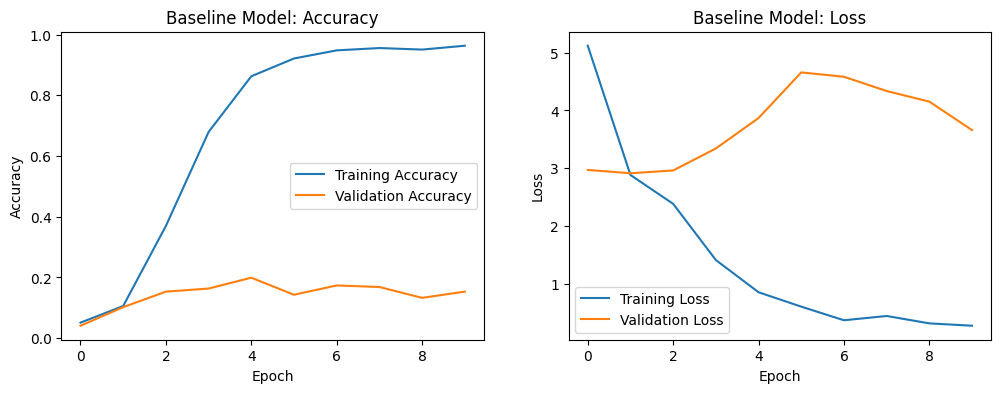

In [46]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 4))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()